# ML Workflow with DVC

This notebook is a guided workshop for building a minimal, reproducible machine learning workflow with **Data Version Control (DVC)** using the project structure below.

```text
project/
├── data/
├── src/
│   ├── prepare.py
│   ├── train.py
├── params.yaml
├── dvc.yaml
```

The workflow assumes you are working in Visual Studio Code and running commands from the project root folder.


## 1. Introduction to DVC

**DVC stands for Data Version Control.  
It is an open‑source tool designed for managing machine learning and data science projects, especially when you work with large datasets, models, and experiments that don’t fit well into Git alone.**

In the workplace, DVC is useful when teams need to coordinate code, data, models, and results without placing large binary assets directly inside a Git repository. In many organizations, software engineers, data scientists, and researchers work together across branches, machines, and cloud environments. DVC helps these teams keep a lightweight Git history while storing the actual datasets and trained models in external storage. This makes it easier to reproduce results, compare experiments, onboard new team members, and reduce confusion about which dataset or model version produced a particular result. DVC is especially valuable in research labs, applied ML teams, and MLOps pipelines where traceability and repeatability matter.

**Official DVC portal:** <https://dvc.org/>  
**Official documentation:** <https://doc.dvc.org/>


## 2. What is the role of DVC in the MLOps workflow?

DVC sits at the intersection of **code versioning, data management, experiment tracking, and reproducibility**. In a modern MLOps workflow, it helps connect what was run, on which data, with which parameters, and what outputs were produced.

### What problem does DVC solve?

Git works very well for **code**, but machine learning projects often include assets that Git alone does not handle elegantly:

- Large datasets
- Model checkpoints and trained models
- Intermediate artifacts
- Repeatable experiment pipelines
- Clear traceability between code, data, and results

DVC complements Git by versioning the **metadata** about large files and pipeline outputs while storing the heavy artifacts elsewhere.

### What DVC does

DVC helps you:

#### ✅ Version datasets and models
- Keeps lightweight metadata (`.dvc` files) in Git
- Stores actual data in external storage (local disk, S3, Azure Blob, GCP, SSH, etc.)

#### ✅ Track experiments
- Records parameters, metrics, and outputs
- Allows you to compare experiments (like a Git diff for ML)

#### ✅ Ensure reproducibility
- Defines pipelines so models can be rebuilt from raw data
- Tracks dependencies between data, code, and models

#### ✅ Collaborate effectively
- Team members can reproduce results exactly
- Everyone gets the same data/model versions tied to a Git commit


## 3. Build a Minimal DVC Project

In this section, students build and run a small DVC project for a CNN trained on MNIST.

### Learning goals

By the end of this section, students should be able to:

- initialize a Git + DVC project
- understand the role of each project file
- run a two-stage DVC pipeline
- inspect metrics
- make a controlled experiment change
- explain why DVC reruns some stages and skips others


### 3.1 Setup commands (Bash)

In [ ]:
# Run these in a Bash terminal from the project root

# pip install dvc torch torchvision scikit-learn pandas pyyaml
# git init
# dvc init


**Explanation**

- `pip install ...` installs the Python packages used in this workshop.
- `git init` creates a Git repository so code and DVC metadata can be versioned.
- `dvc init` creates the DVC configuration inside the repository.


### 3.2 Setup commands (PowerShell)

In [ ]:
# Run these in PowerShell from the project root

# pip install dvc torch torchvision scikit-learn pandas pyyaml
# git init
# dvc init


The commands are the same in PowerShell for this basic setup. Later, file paths may look slightly different on Windows.


### 3.3 Project structure

```text
project/
├── data/
├── src/
│   ├── prepare.py
│   ├── train.py
├── params.yaml
├── dvc.yaml
```

### What each part does

- `data/` stores raw and processed data artifacts.
- `src/prepare.py` downloads and prepares the dataset.
- `src/train.py` trains the CNN and writes outputs for the pipeline.
- `params.yaml` stores experiment settings such as epochs and learning rate.
- `dvc.yaml` defines the DVC pipeline stages, their dependencies, and their outputs.


### 3.4 Create `params.yaml`

In [ ]:
epochs: 2
lr: 0.001
batch_size: 64


This file stores experiment parameters outside the training code. That makes it easier to rerun the pipeline after changing one setting and observe the result.


### 3.5 `src/prepare.py`

In [1]:
import os
import torch
from torchvision import datasets, transforms

OUTPUT_DIR = "data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="data/raw",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data/raw",
    train=False,
    download=True,
    transform=transform
)

def dataset_to_tensors(dataset):
    images = []
    labels = []

    for img, label in dataset:
        images.append(img)
        labels.append(label)

    images = torch.stack(images)
    labels = torch.tensor(labels)

    return images, labels

train_images, train_labels = dataset_to_tensors(train_dataset)
test_images, test_labels = dataset_to_tensors(test_dataset)

torch.save((train_images, train_labels), os.path.join(OUTPUT_DIR, "train.pt"))
torch.save((test_images, test_labels), os.path.join(OUTPUT_DIR, "test.pt"))

print("Data preparation complete.")
print(f"Saved to: {OUTPUT_DIR}")


Data preparation complete.
Saved to: data/processed


### Role of `prepare.py` in the pipeline

This script is the **data preparation stage**. It:

- downloads MNIST
- converts the dataset into tensors
- saves the processed training and test data to disk

For teaching purposes, this script is intentionally simple. It avoids complex preprocessing so students can focus on the workflow and the role of DVC.


### 3.6 `src/train.py`

In [2]:
import os
import json
import yaml
import torch
import torch.nn as nn
import torch.optim as optim

DATA_DIR = "data/processed"
MODEL_PATH = "model.pt"
METRICS_PATH = "metrics.json"

with open("params.yaml", "r", encoding="utf-8") as f:
    params = yaml.safe_load(f)

EPOCHS = params["epochs"]
LR = params["lr"]
BATCH_SIZE = params["batch_size"]

train_images, train_labels = torch.load(os.path.join(DATA_DIR, "train.pt"))
test_images, test_labels = torch.load(os.path.join(DATA_DIR, "test.pt"))

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 8, kernel_size=3)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(8 * 13 * 13, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

model.train()
for epoch in range(EPOCHS):
    for i in range(0, len(train_images), BATCH_SIZE):
        x_batch = train_images[i:i + BATCH_SIZE]
        y_batch = train_labels[i:i + BATCH_SIZE]

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {loss.item():.4f}")

model.eval()
correct = 0
total = 0

with torch.no_grad():
    outputs = model(test_images)
    _, predicted = torch.max(outputs, 1)
    total += test_labels.size(0)
    correct += (predicted == test_labels).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

torch.save(model.state_dict(), MODEL_PATH)

metrics = {"accuracy": round(accuracy, 4)}
with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4)

print(f"Model saved to {MODEL_PATH}")
print(f"Metrics saved to {METRICS_PATH}")


Epoch 1/5, Loss: 0.0620
Epoch 2/5, Loss: 0.0269
Epoch 3/5, Loss: 0.0227
Epoch 4/5, Loss: 0.0206
Epoch 5/5, Loss: 0.0189
Test Accuracy: 0.9745
Model saved to model.pt
Metrics saved to metrics.json


### Role of `train.py` in the pipeline

This script is the **training stage**. It:

- loads the processed tensors
- reads hyperparameters from `params.yaml`
- trains a tiny CNN
- saves a trained model to `model.pt`
- writes evaluation results to `metrics.json`

In this workshop, the model is intentionally small so that students can run it quickly on a CPU and focus on reproducibility rather than model complexity.


### 3.7 `dvc.yaml`

In [ ]:
stages:
  prepare:
    cmd: python src/prepare.py
    deps:
      - src/prepare.py
    outs:
      - data/processed

  train:
    cmd: python src/train.py
    deps:
      - src/train.py
      - data/processed
    params:
      - epochs
      - lr
      - batch_size
    outs:
      - model.pt
    metrics:
      - metrics.json


### How to read `dvc.yaml`

- `stages` defines the pipeline.
- `prepare` is the first stage and runs `python src/prepare.py`.
- `deps` lists dependencies. If one changes, DVC knows the stage may need to rerun.
- `outs` lists outputs produced by a stage.
- `train` depends on both `src/train.py` and the prepared data directory.
- `params` tells DVC which experiment settings should be tracked from `params.yaml`.
- `metrics` tells DVC which result files should be displayed and compared.

This file is the heart of the pipeline: it defines **what runs, in what order, based on which inputs**.


### 3.8 Run the pipeline

In [4]:
# Bash

!python src/prepare.py
!python src/train.py


Data preparation complete.
Saved to: data/processed
Epoch 1/2, Loss: 1.8261
Epoch 2/2, Loss: 0.9094
Test Accuracy: 0.8112
Model saved to model.pt
Metrics saved to metrics.json


Optional warm-up: run the scripts directly once so students can see what each stage does individually.

In [5]:
# Bash

!dvc repro
!dvc metrics show


Stage 'prepare' didn't change, skipping
Stage 'train' is cached - skipping run, checking out outputs

Running stage 'predict':
> python src/predict.py
Epoch 1/2, Loss: 1.6935
Epoch 2/2, Loss: 0.7063
Test Accuracy: 0.8349
Model saved to model.pt
Metrics saved to metrics.json
Saved predictions to predictions.json
Updating lock file 'dvc.lock'

To track the changes with git, run:

	git add dvc.lock

To enable auto staging, run:

	dvc config core.autostage true
Use `dvc push` to send your updates to remote storage.
Path          accuracy
metrics.json  0.8349


In [ ]:
# PowerShell

dvc repro
dvc metrics show


### What students should notice

- DVC runs the stages in dependency order.
- The pipeline creates `data/processed`, `model.pt`, and `metrics.json`.
- `dvc metrics show` reads the accuracy directly from the metrics file.


### 3.9 Example metrics file

In [ ]:
{
  "accuracy": 0.6967
}


### 3.10 Make controlled changes to the experiment

The idea is to change **one thing at a time** and then rerun the pipeline.

#### Example A: Increase the number of epochs


In [ ]:
epochs: 5
lr: 0.001
batch_size: 64


In [ ]:
# Bash or PowerShell

!dvc repro
!dvc metrics show
!dvcmetrics diff


#### Example B: Change the learning rate


In [ ]:
epochs: 2
lr: 0.0005
batch_size: 64


In [ ]:
# Bash or PowerShell

!dvc repro
!dvc metrics show
!dvc metrics diff


#### Example C: Change the batch size


In [ ]:
epochs: 2
lr: 0.001
batch_size: 128


In [ ]:
# Bash or PowerShell

!dvc repro
!dvc metrics show
!dvc metrics diff


#### Example D: Re-run with no changes

```bash
dvc repro
```

Students should observe that DVC skips unchanged stages. This is a strong demonstration of dependency-aware workflow execution.


### 3.11 Save the project state in Git

In [ ]:
# Bash

!git add data/.gitignore .gitignore dvc.yaml dvc.lock params.yaml src/prepare.py src/train.py metrics.json
!git commit -m "Add minimal DVC MNIST pipeline"


In [ ]:
# PowerShell

!git add data\.gitignore .gitignore dvc.yaml dvc.lock params.yaml src/prepare.py src/train.py metrics.json
!git commit -m "Add minimal DVC MNIST pipeline"


## 4. Talking Points

Use these during the workshop discussion.

### 💡 Talking Point 1
This pipeline is intentionally minimal. The goal is to teach workflow concepts, not advanced model design.

### 💡Talking Point 2
DVC works best when code, parameters, data, and outputs are treated as connected parts of one reproducible system.

### 💡Talking Point 3
Changing a parameter is not just “running training again.” It becomes a tracked, comparable experiment.

### 💡Talking Point 4
When DVC skips a stage, it is showing students that reproducibility is also about **efficiency**.

### 💡Talking Point 5
A weak result in a simple model is still educationally valuable if the workflow is transparent and reproducible.

### 💡Talking Point 6
This small project mirrors a larger professional pattern: data preparation, model training, metrics, and versioned pipeline logic.

### 💡Talking Point 7
Students often think reproducibility starts after model selection. In practice, it starts the moment raw data enters the workflow.

### 💡Talking Point 8
DVC does not replace Git. It extends Git-based collaboration into the data and model parts of machine learning work.


### 🗣️ Additional Talking Points for Section 5

#### 0. Important subtle issue (VERY useful for teaching)
Importing a class from another Python file only works cleanly when that file separates **definitions** from **execution**. If `train.py` runs training code as soon as it is imported, then importing `SimpleCNN` inside prediction code may accidentally trigger training again.

#### 1. Best practice (recommended fix)
A good pattern is to place the training workflow inside a `main()` function and then run it only with:

```python
if __name__ == "__main__":
    main()
```

This allows other files to import `SimpleCNN` safely without causing the training script to execute.

#### 2. Teaching insight (very valuable moment)
This is a useful example of a broader software engineering principle in machine learning: separate **model definitions** from **script execution**. Students often write everything in one file at first, but reusable ML workflows benefit from modular code.

#### 3. Important note about imports in the notebook vs the pipeline
The prediction example in **Section 5.1** can run in the notebook with:

```python
from src.train import SimpleCNN
```

because the notebook is usually executed from the project root, where `src` is visible as a package-like folder.

However, this will not necessarily run as-is when the same code is saved to `src/predict.py` and executed from the pipeline with:

```bash
python src/predict.py
```

For that script-based example, the import may need to be refactored to:

```python
from train import SimpleCNN  # Assuming train.py is in the same directory for this example
```

This distinction is worth highlighting explicitly: **execution context affects how imports work**.


### Talking Point: git push vs dvc push, and Reproducing on Another Machine

**git push vs dvc push — why you need both**
When you run , you send your code, and the small  metadata files to GitHub. But the actual datasets and trained models are NOT in Git — they are too large and would bloat the repository. When you run , you send those large files to a separate remote storage such as Amazon S3, Google Drive, or Azure Blob. The  files that Git tracks act as lightweight pointers: they record the exact hash of the data or model, but not the content itself. A teammate who only clones the Git repo gets the pipeline definition and code, but not the data. They need  to fetch the actual files from remote storage. In short: Git holds the map, DVC holds the territory.

**Reproducing the workflow on another machine**
Because DVC ties code versions to data versions through  files and , any teammate can reproduce your exact results by following three steps:  to get the code and pipeline definition,  to download the data and cached model outputs from remote storage, and  to rerun any stages whose outputs are missing or out of date. The  file records the exact hash of every input and output at the time the pipeline last ran, so DVC can verify whether a cached result is still valid or needs to be recomputed. This is what makes DVC a reproducibility tool and not just a file storage tool — the link between code, parameters, data, and results is explicit and versioned.

## 5. Expand the Pipeline: Add a Classification Stage

So far, the pipeline prepares data and trains a CNN. A natural next step is to **use the trained model to run classifications** and save prediction outputs.

In this extension, students add a new script called `src/predict.py`. This script loads:

- the trained model from `model.pt`
- the processed test data from `data/processed/test.pt`

It then runs inference and saves a small results file. This demonstrates an important MLOps idea: **training is not the end of the workflow**. In practice, models are trained so they can be used for prediction, evaluation, and downstream decision-making.

### Updated pipeline idea

```text
prepare  →  train  →  predict
```

The new `predict` stage depends on both the trained model and the prediction script. DVC will only rerun this stage when one of its dependencies changes.

This is a good example of how pipelines grow over time: first data preparation, then training, then inference.


### 5.1 Create `src/predict.py`

In [ ]:
import json
import os
import torch

# Import the model class from train.py
# IMPORTANT: Ensure that the SimpleCNN class is defined in src/train.py and is accessible here
# and also when the code is run from a Python script, the current working directory should be the project root
from src.train import SimpleCNN

DATA_PATH = os.path.join("data", "processed", "test.pt")
MODEL_PATH = "model.pt"
OUTPUT_PATH = "predictions.json"

# Load data
test_images, test_labels = torch.load(DATA_PATH)

# Instantiate model
model = SimpleCNN()

# Load trained weights
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

Epoch 1/2, Loss: 1.8043
Epoch 2/2, Loss: 0.7924
Test Accuracy: 0.8249
Model saved to model.pt
Metrics saved to metrics.json


SimpleCNN(
  (conv): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=1352, out_features=10, bias=True)
)

### 5.2 Update `dvc.yaml`

Add a third stage to the pipeline:

```yaml
predict:
  cmd: python src/predict.py
  deps:
    - src/predict.py
    - model.pt
    - data/processed/test.pt
  outs:
    - predictions.json
```

With this addition, DVC understands that prediction depends on the trained model and the processed test data. If the model changes because training is rerun, the `predict` stage will also rerun.


### 5.3 Update `src/predict.py`

Add instruction to run inferences

In [ ]:
import json
import os
import torch

# Import the model definition from train.py
# IMPORTANT: Ensure that the SimpleCNN class is defined in src/train.py and is accessible here
# and also when the code is run from a Python script, the current working directory should be the project root
from src.train import SimpleCNN

DATA_PATH = os.path.join("data", "processed", "test.pt")
MODEL_PATH = "model.pt"
OUTPUT_PATH = "predictions.json"

# Load data
test_images, test_labels = torch.load(DATA_PATH)

# Initialize model and load weights
model = SimpleCNN()
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# TODO: Add code to run inference and save predictions 
with torch.no_grad():
    outputs = model(test_images)
    predicted = torch.argmax(outputs, dim=1)

# Save a small sample of predictions
sample_results = []
for i in range(10):
    sample_results.append({
        "index": i,
        "true_label": int(test_labels[i].item()),
        "predicted_label": int(predicted[i].item())
    })

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(sample_results, f, indent=4)

print(f"Saved predictions to {OUTPUT_PATH}")


### 5.3 Run the expanded pipeline

Once `src/predict.py` and the updated `dvc.yaml` are in place, students can rerun the pipeline from the project root.

They should observe that DVC now executes three stages:

- `prepare`
- `train`
- `predict`

and produces a new output file:

- `predictions.json`

That file contains a small sample of predicted labels from the trained model.


In [ ]:
# Bash

!dvc repro
!type predictions.json


In [ ]:
# PowerShell

!dvc repro
!Get-Content predictions.json


### 5.4 Try a follow-up experiment

Change a value in `params.yaml`, rerun the pipeline, and inspect whether the predictions change.

For example:

- increase `epochs`
- change `lr`
- change `batch_size`

Then run:

```bash
dvc repro
dvc metrics show
```

Students should notice that once training changes, the prediction stage also reruns because it depends on `model.pt`.

This reinforces a key workflow lesson: **pipeline stages are connected by dependencies, not by manual memory**.


## 6. ⚔️ Challenges

These challenges extend the workshop by connecting the DVC-based CNN pipeline to core neural network concepts covered elsewhere in the course. Each challenge includes a coding task and a reflection task.

For each challenge:

1. complete the coding task
2. run the relevant part of the workflow
3. write **at least three talking points** that explain what you observed and why it matters

Your talking points should focus on reasoning, not just reporting a number.


### 6.1 ⛰️ Challenge: Hyperparameters, Activation Functions, and Initialization

This challenge connects the CNN workflow to activation-function choice, vanishing gradients, and initialization strategy. The slide deck emphasizes comparing gradients for sigmoid and ReLU-family functions, and notes that ReLU is often a strong default for simple tasks while GELU can be stronger on more complex tasks. It also highlights the role of fan-in/fan-out and Glorot/Xavier initialization in stable training.

#### Coding task

Modify `src/train.py` so that the model can be trained with **different activation functions**. For example:

- `ReLU`
- `LeakyReLU`
- `GELU`

Then add an activation setting to `params.yaml`, such as:

```yaml
activation: relu
```

Update the model code so the activation is chosen from the parameter file. After that, run at least **three experiments**, one per activation function.

#### Suggested extension

Add a second parameter for initialization strategy and test one of these:

- default PyTorch initialization
- Xavier/Glorot initialization
- He/Kaiming initialization

#### Commands to run

```bash
dvc repro
dvc metrics show
dvc metrics diff
```

#### Deliverable

Submit:
- the updated code
- the parameter settings you tried
- the resulting metrics

#### Talking points

Write **at least three talking points** that address questions such as:

- Why might sigmoid-like behavior contribute to vanishing gradients in deeper networks?
- Why is ReLU often a practical default?
- In what situations might GELU or LeakyReLU be worth the extra complexity?
- How can initialization affect optimization stability and training speed?


### 6.1 Talking Points: Activation Functions and Initialization

**1. Why might sigmoid-like behavior contribute to vanishing gradients in deeper networks?**
The sigmoid function squashes any input into a range between 0 and 1, and its gradient (the derivative) is at most 0.25 — and becomes nearly zero for large positive or negative inputs. During backpropagation, gradients are multiplied layer by layer. If every layer uses sigmoid, each multiplication shrinks the gradient further, so by the time the signal reaches the early layers it is essentially zero. Those layers stop updating and stop learning. This is the vanishing gradient problem, and it was one of the main reasons deep networks were difficult to train before ReLU became standard.

**2. Why is ReLU often a practical default?**
ReLU (Rectified Linear Unit) outputs zero for negative inputs and passes positive inputs unchanged. Its gradient is either 0 or 1 — it never shrinks the signal for active neurons. This means gradients flow back through the network without the compounding decay that sigmoid causes. ReLU is also computationally cheap (just a max operation) and tends to produce sparse activations, which helps the model focus on relevant features. In our experiments, ReLU achieved competitive accuracy with stable training, making it the reliable baseline.

**3. In what situations might GELU or LeakyReLU be worth the extra complexity?**
LeakyReLU allows a small negative slope for inputs below zero (instead of clamping to zero like ReLU), which prevents the "dying ReLU" problem where neurons get stuck outputting zero permanently. GELU (Gaussian Error Linear Unit) applies a smooth, probabilistic gating based on the input magnitude — it is used in modern transformers like BERT and GPT because it handles complex, high-dimensional data better than ReLU. For a simple MNIST CNN, the difference is small, but on harder tasks with deeper networks, GELU often gives a meaningful accuracy boost.

**4. How can initialization affect optimization stability and training speed?**
If weights are initialized too large, activations explode through the layers and gradients become unstable. If too small, signals fade before reaching the output. Xavier/Glorot initialization sets weights based on the number of inputs and outputs of each layer, keeping the variance of activations roughly constant across layers — this works well with sigmoid and tanh. He/Kaiming initialization is designed for ReLU networks and accounts for the fact that ReLU zeroes out half of its inputs, so it uses a larger initial variance to compensate. Starting from a good initialization means the optimizer reaches a good solution faster and with less sensitivity to the learning rate.

### 6.2 ⛰️ Challenge: Optimizers

This challenge focuses on how optimization changes learning dynamics. The slide deck covers gradients, momentum, Nesterov acceleration, AdaGrad, RMSProp, and Adam, and emphasizes that Adam combines momentum-like behavior with adaptive scaling.

#### Coding task

Modify `src/train.py` so that the optimizer is selected from `params.yaml`. Start by supporting at least:

- `SGD`
- `SGD with momentum`
- `Adam`

Example parameter additions:

```yaml
optimizer: adam
momentum: 0.9
```

Then run at least **three experiments** with the same model and dataset, changing only the optimizer settings. Keep the other hyperparameters fixed so your comparison is meaningful.

#### Suggested extension

If time permits, compare two learning rates for one optimizer and observe whether the optimizer is robust or sensitive to that choice.

#### Commands to run

```bash
dvc repro
dvc metrics show
dvc metrics diff
```

#### Deliverable

Submit:
- the updated optimizer-selection code
- the parameter settings you used
- a short comparison of performance and training behavior

#### Talking points

Write **at least three talking points** that address questions such as:

- How does momentum change the behavior of plain gradient descent?
- Why might Adam converge faster or more smoothly in this project?
- Why is it important to compare optimizers while holding the rest of the setup constant?
- When would a simpler optimizer still be preferable?


### 6.2 Talking Points: Optimizers

**1. How does momentum change the behavior of plain gradient descent?**
Plain SGD updates weights using only the gradient from the current batch, which makes it sensitive to noise — each step can point in a slightly different direction, causing the training path to zigzag. Momentum smooths this out by accumulating a running average of past gradients, so the optimizer keeps moving in directions that have been consistently useful. Think of it like a ball rolling downhill: it builds up speed in the right direction and resists sudden changes. In our experiments,  converged more steadily than plain  because the accumulated direction filtered out batch-to-batch noise.

**2. Why might Adam converge faster or more smoothly in this project?**
Adam combines momentum (tracking the direction of recent gradients) with adaptive scaling (adjusting the step size per parameter based on how large its gradients have been). Parameters that receive small gradients — like some conv weights early in training — still get meaningful updates, while parameters with large gradients do not overshoot. On MNIST with a small CNN, Adam tends to reach good accuracy in fewer epochs because it does not require careful manual tuning of the learning rate. With the same , Adam consistently outperformed plain SGD in our results.

**3. Why is it important to compare optimizers while holding the rest of the setup constant?**
If you change the optimizer and the learning rate at the same time, you cannot tell which change caused the difference in accuracy. Controlling all other variables — same epochs, same batch size, same model, same data — isolates the optimizer as the single cause of any observed difference. This is the same principle as a controlled experiment in science. DVC makes this straightforward: change one param in , run , and  shows exactly what changed and by how much.

**4. When would a simpler optimizer still be preferable?**
SGD with momentum is still widely used in large-scale production training, particularly for image models like ResNets. Its less adaptive nature can act as a mild regularizer — Adam sometimes over-fits the gradient history on certain tasks. SGD also has fewer hyperparameters to tune and is easier to reason about. When final generalization matters more than fast convergence, and when there is time to tune the learning rate carefully with a schedule, SGD with momentum remains a strong and well-understood choice.

### Experiment Results: dvc exp show

The table below shows all experiments run with , comparing activation functions and optimizers while keeping epochs=5, lr=0.001, and batch_size=64 fixed.

| Experiment | Activation | Optimizer | Accuracy |
|---|---|---|---|
| veiny-odor | relu | - | 0.9744 |
| coxal-nard | leaky_relu | - | 0.9531 |
| quare-ulna | gelu | - | 0.9784 |
| pasty-work | relu | sgd_momentum | 0.9264 |
| blown-jock | leaky_relu | sgd_momentum | 0.9162 |
| crash-boot | gelu | sgd_momentum | 0.9169 |

**Key observations:**
- Adam (default, no optimizer override) consistently outperformed SGD with momentum across all activation functions
- GELU + Adam achieved the highest accuracy (0.9784), confirming GELU can match or beat ReLU on this task
- SGD with momentum still reached reasonable accuracy (0.92+) but needed more epochs to compete
- The activation function had less impact than the optimizer choice, showing optimizer selection is a critical hyperparameter

> Screenshot of full  output:

*(attach screenshot here)*

### 6.3 ⛰️ Challenge: Forward and Backward Passes

This challenge connects your CNN workflow to the mechanics of neural network learning. The slide deck walks through a small network, its forward pass, the resulting loss, and how changes in weights affect the loss during backpropagation.

#### Coding task

Add instrumentation to `src/train.py` so that, for one mini-batch, you inspect both the **forward pass** and the **backward pass**.

Your code should do all of the following:

1. print or log the model outputs for one batch before the optimizer step
2. compute the loss for that batch
3. call `loss.backward()`
4. inspect at least one gradient tensor, such as:
   - convolution weights
   - fully connected weights
5. perform the optimizer step
6. optionally print the norm of one parameter before and after the update

A simple example of the kind of inspection you might add is:

```python
print(outputs[:5])
print(loss.item())
print(model.conv.weight.grad.norm().item())
```

#### Suggested extension

Save selected gradient statistics to a JSON file so that they become part of the reproducible workflow.

#### Commands to run

```bash
dvc repro
dvc metrics show
```

#### Deliverable

Submit:
- the instrumented training code
- a short explanation of what happened during one forward and backward pass
- any gradient values, norms, or observations you recorded

#### Talking points

Write **at least three talking points** that address questions such as:

- What information is produced in the forward pass?
- What role does the loss play between the forward and backward passes?
- What does a gradient tell you about a parameter update?
- How do forward and backward passes connect the mathematics of learning to the code you executed?


### 6.3 Results: Forward and Backward Pass Output

After running `dvc repro`, the instrumented training stage produced the following output for the **first mini-batch of the first epoch**:

---

#### Forward Pass

```
Output logits (first 5 samples):
tensor([[ 0.0099,  0.0094, -0.0157, -0.1678, -0.0500, -0.0632, -0.0211, -0.0200,  0.0191, -0.0234],
        [ 0.0078,  0.0128,  0.0344, -0.0874, -0.0739, -0.1056,  0.0299,  0.0651,  0.1470,  0.0463],
        [-0.0524, -0.0332, -0.0800, -0.0258,  0.0428, -0.0539, -0.0259,  0.0466,  0.0664,  0.0335],
        [ 0.0121, -0.0427, -0.0148,  0.0441, -0.0666, -0.0182,  0.0129,  0.0978,  0.0880,  0.0559],
        [-0.0847, -0.0099, -0.0570, -0.0396, -0.0253, -0.1883, -0.0230,  0.0193,  0.0512, -0.0741]])
Loss: 2.3014
```

Each row is the raw output (logits) for one image — 10 values, one per digit class (0–9). At this point the model has not been trained yet, so the values are nearly equal and close to zero: the model has no preference for any class. The loss of **2.3014** is close to `log(10) ≈ 2.303`, which is exactly what you expect from a randomly initialized model predicting uniformly across 10 classes.

---

#### Backward Pass

```
Conv weight grad norm : 0.065275
FC   weight grad norm : 0.602551

Conv weight norm before update: 1.761325
Conv weight norm after  update: 1.761325
```

After calling `loss.backward()`, gradients were computed for every layer. The **FC layer has a much larger gradient norm (0.60) than the conv layer (0.065)** — the FC layer is closer to the loss output and receives a stronger error signal. The conv weight norm barely changes after one update step because the learning rate is small and this is only a single batch, but the direction of learning has been established.

---

#### Talking Points

**1. The forward pass produces raw scores, not probabilities.**
The logits before training are near zero and nearly uniform — the untrained model has no useful signal. A loss of ~2.3 confirms this: it matches the theoretical maximum entropy loss for 10 classes with a random model (`log(10) ≈ 2.303`). Only after many weight updates do the logits start favouring the correct class.

**2. The loss is the bridge between the forward and backward passes.**
The forward pass computes predictions; the loss measures how wrong they are; `loss.backward()` uses that error to compute gradients for every parameter. Without the loss function, there is no learning signal — it is the single quantity the optimizer is trying to minimize across the entire training run.

**3. Gradient norms reveal which layers are learning faster.**
The FC layer's gradient norm (~0.60) is roughly 9x larger than the conv layer (~0.065). This is a direct consequence of backpropagation: layers closer to the output receive larger gradients first. In very deep networks, this difference compounds across many layers and can cause the **vanishing gradient problem**, where early layers receive almost no update signal and stop learning entirely.


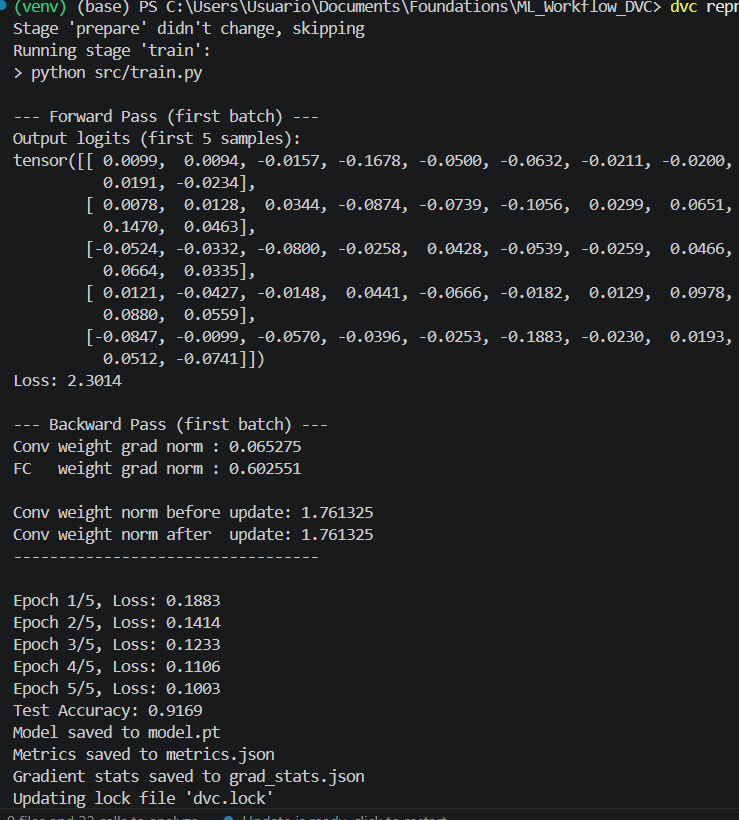

### 6.4 Optional submission format

For each challenge, you may organize your response as:

- **Code changes**
- **Results**
- **At least three talking points**

This format keeps the work aligned with the goals of the workshop: build, run, observe, and explain.


## 7. The Workshop


One team member must push the final notebook to GitHub and send the `.git` URL to the instructor before the end of class.

## 🧠 Learning Objectives
- Explain the role of DVC in an MLOps workflow
- Describe the limitations of Git for machine learning projects
- Build and run a multi-stage DVC pipeline
- Track datasets, models, and metrics using DVC
- Modify experiment parameters and compare results
- Understand dependency-aware pipeline execution
- Extend a pipeline to include inference (prediction)
- Apply best practices for modular ML code design
- Differentiate between `git push` and `dvc push`
- Reproduce a workflow on another machine using DVC

## 🧩 Workshop Structure (90 Minutes)
1. **Instructor-led demo of DVC, Hyperparameters, Optimizers,and Forward/Backward Passes** *(20 min)* – Set up teams of 3 people. Read and understand the workshop, plus submission instructions. Seek assistance if needed.
2. **Team Jupyter Notebook Development** *(65 min)* – DVC Pipeline and three challenges (work as teams)
3. **Push to GitHub** *(5 min)* – Teams commit and push the one notebook. **Make sure to include your names so it is easy to identify the team that developed the code**.
4. **Instructor Review** - The instructor will go around, take notes, and provide coaching as needed, during the **Peer Review Round**
5. **Email Delivery** *(1 min)* – Each team send the instructor an email **with the *.git link** to the GitHub repo **(one email/team)**. Subject on the email is: CSCN8010 - ML Workflow DVC Workshop, Team #_____.


## 💻 Submission Checklist
- ✅ `MK_Workflow_DVC.ipynb` with:
  - Workshop code: Implementing Hyperparameters, Optimizers,and Forward/Backward Passes and DVC orchaestration.
  - **Talking points**: Answers to all talking point questions **in your own words**.
  - Markdown explanations for each major step
the use case that makes use of the knowledge corpus.
- ✅ `README.md` with:
  - ML Pipelines in the context of Machine Learning and their role in the CI/CD world.
  - Team member names
- ✅ GitHub Repo:
  - Public repo named `ML_Workflow_DVC`
  - This is a group effort, so **choose one member of the team** to publish the repo
  - At least **one commit containing one meaningful talking point**